### RNN(순환 신경망)
- 이전 시점의 정보를 현재 시점의 계산에 반영하는 구조

    - 첫번째 입력
        - 초기 상태(h_0 = 0)와 입력에 대한 상태(h_1)로 계산
    - 두번째 입력
        - 이전의 상태(h_1)와 결합해서 계산 (h_2)
    - 세번째 입력
        - 이전의 입력 상태(h_2)와 현재의 상태를 결합해서 계산(h_3)
    - 반복 작업이 완료되었을때
        - 마지막 상태(h_t) 생성 -> 모든 과거의 정보를 결합해놓은 상태

- parameter
    - input_size
        - 각 시점(레이어)에서 입력의 피쳐의 수
    - hidden_size
        - 은닉층(출력)의 크기
    - num_layers
        - 기본값 : 1
        - RNN 층의 개수 (층이 깊어질수록 복잡한 패턴을 발생)
        - 층의 개수가 늘어날수록 시간은 증가하고 과적합의 위험성이 존재
        - 1~3 정도 사용을 하고 1부터 개수를 1씩 증가시키면서 사용
    - nonlinearity
        - 기본값 : 'tanh'
        - 비선형 활성화 함수를 선택
    - batch_first
        - 기본값 : False
        - 입력 텐서에서 첫번째 차원이 배치인지 여부
    - bias
        - 기본값 : True
        - 각 가중치에 편향 항을 추가 여부
    - dropout
        - 기본값 : 0.0
        - 층 사이에 Dropout의 적용 비율 -> 층이 2개 이상인 경우에만 사용
    - bidirectional
        - 기본값 : False
        - 양방향 RNN을 사용할지 여부 (순방향은 기본, 역방향을 사용할것인가?)

- parameter 설정시 유의할 점
    - hidden_size
        - 너무 적은 경우라면 정보가 부족, 너무 큰 경우라면 과적합
        - 일반적으로는 32, 64, 128
    - num_layers
        - 시간의 복잡도에 따라서 1 ~ 3 정도를 이용
        - 1부터 테스트를 돌려서 교차 검증
    - nonlinearity
        - 일반적으로 'tanh'을 사용, relu를 사용하면 시간이 감소하지만 발산의 위험성이 존재
    - dropout
        - 층이 2개 이상인 경우에만 사용
        - 과적합 방지를 위해 사용 0.2 ~ 0.5 사이의 값을 사용(권장사항)

In [104]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [105]:
# 랜덤 시드 고정
np.random.seed(42)
torch.manual_seed(42)


In [106]:
# 노이즈를 포함한 연속성을 가진 sin곡선을 생성
x = torch.arange(3000).float()
y = torch.sin(2 * math.pi * 0.02 * x) + 0.05 * torch.randn(3000)

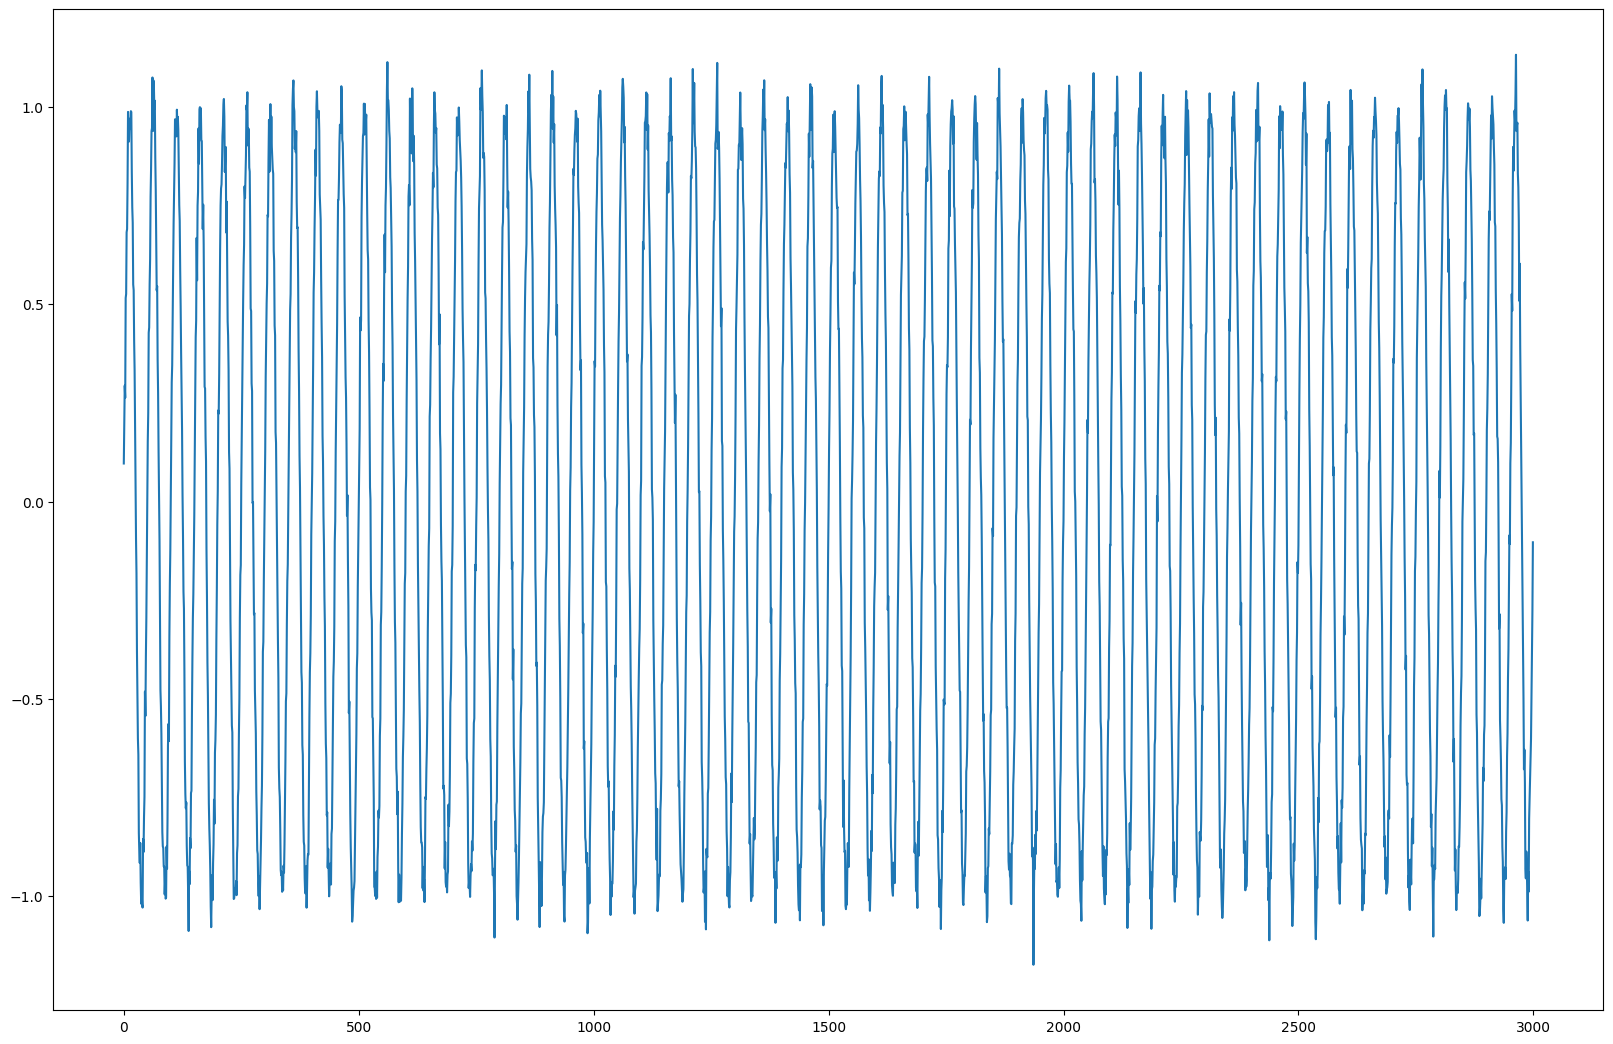

In [107]:
plt.figure(figsize = (20,13))
plt.plot(x,y)
plt.show()

In [108]:
x

tensor([0.0000e+00, 1.0000e+00, 2.0000e+00,  ..., 2.9970e+03, 2.9980e+03,
        2.9990e+03])

In [109]:
# train, test 데이터셋 분할 8:2 -> 앞의 80% train, 뒤의 20% test
train_size = int(0.8 * len(x))
train_size

2400

In [110]:
# X_train = x[:train_size]
X_train = y[:train_size]
# X_test = x[train_size:]
X_test = y[train_size:]

In [111]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train.reshape(-1,1))
X_test_sc = scaler.transform(X_test.reshape(-1,1))

In [112]:
X_train_sc

array([[ 0.13549958],
       [ 0.28142013],
       [ 0.41417719],
       ...,
       [-0.56898224],
       [-0.31882725],
       [-0.10808127]], shape=(2400, 1))

In [113]:
X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

In [114]:
X_train_tensor.shape

torch.Size([2400, 1])

In [115]:
# Tensor Data를 배치가 존재하는 3차원 데이터로 변환
X_train_tensor = X_train_tensor.unsqueeze(0)
X_test_tensor = X_test_tensor.unsqueeze(0)

X_train_tensor.shape
    # (2400, 1) -> (2400, 1, 1)

torch.Size([1, 2400, 1])

In [116]:
class RNN_Model(nn.Module):
    def __init__(self):
        super(RNN_Model, self).__init__()
        self.rnn = nn.RNN(
            input_size = 1,
            hidden_size = 64,
            num_layers = 1,
            batch_first = True,
            dropout = 0.0,
            nonlinearity = 'tanh',
            bidirectional = False
        )
        self.linear = nn.Linear(64, 1)
    def forward(self, x):
        # RNN 모델에서 되돌려주는 데이터는 2개를 되돌려준다 ->
        # 첫번째 데이터 : 모든 시점에서의 은닉층의 값
        # 두번째 데이터 : 마지막 시점에서의 은닉층의 값 -> 층이 존재하는 경우 마지막 층의 값을 추출
        out, h_n = self.rnn(x)
        result = self.linear(h_n[-1])
        return result

In [117]:
model = RNN_Model()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

### DataLoader
- Pytorch에서 DataSet들을 효율적으로 배치 단위로 꺼내주는 반복자
- 반복 학습 루트에 맞는 형태의 데이터셋을 공급해주는 역할
- parameter
    - batch_size
        - Dataset들을 모아서 텐서의 형태로 묶어준다
    - shuffle
        - 에폭마다 데이터의 순서를 랜덤하게 변경
    - drop_last
        - window(구간)에 맞는 구간을 나눠주고 마지막 구간에서 데이터의 개수가 window가 작은 경우에는 해당 배치를 제거
    - pin_memory
        - GPU 사용시 True로 변경하면 CPU -> GPU 전송이 빨라짐

In [118]:
# Custom Dataset 클래스 정의
class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        # _data : 시계열 데이터
        # _window : 구간 설정
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수 계산
        # 입력 데이터 : 전체 길이 - window 크기
        self.n = len(self.data) - self.window
    # __len__ 메서드 : 인덱스에 해당하는 샘플을 반환
    # __getitem__ 메서드 : 인덱스에 해당하는 샘플을 반환
    # 특수 메서드 : DataLoader가 데이터셋에서 데이터를 불러올때 자동으로 호출
    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        # DataLoader 실제로 입력이 된 데이터들을 슬라이스해서 가지고가는 함수
        # idx -> 0 // data[0 : 10] -> idx(0~9) -> 문제 데이터
        x = self.data[idx : idx + self.window]
        # data[10] -> 11번째 데이터 -> 정답 데이터
        y = self.data[idx + self.window]
        return x, y

In [119]:
window = 10
train_ds = WindowDataset(X_train_tensor.squeeze(0), window)


In [120]:
len(X_train_tensor.squeeze(0))

2400

In [121]:
len(train_ds)

2390

In [122]:
train_ds.__getitem__(0)

(tensor([[0.1355],
         [0.2814],
         [0.4142],
         [0.3706],
         [0.7275],
         [0.7422],
         [0.9629],
         [0.9741],
         [1.1385],
         [1.3934]]),
 tensor([1.3145]))

In [123]:
train_ds.__getitem__(2389)

(tensor([[-1.3785],
         [-1.3544],
         [-1.2372],
         [-1.1063],
         [-1.0325],
         [-0.9312],
         [-0.7994],
         [-0.7397],
         [-0.5690],
         [-0.3188]]),
 tensor([-0.1081]))

In [124]:
batch_size = 10
x_list = []
y_list = []

for i in range(len(train_ds)):
    if i == 10:
        break
    x, y = train_ds[i]
    x_list.append(x)
    y_list.append(y)

    print(f"입력 데이터 : {x.squeeze().tolist()} / 정답 데이터 : {y.item()}")

입력 데이터 : [0.13549958169460297, 0.28142011165618896, 0.41417717933654785, 0.37058213353157043, 0.7275432348251343, 0.7422033548355103, 0.962931215763092, 0.9740656614303589, 1.1384670734405518, 1.39337158203125] / 정답 데이터 : 1.3145451545715332
입력 데이터 : [0.28142011165618896, 0.41417717933654785, 0.37058213353157043, 0.7275432348251343, 0.7422033548355103, 0.962931215763092, 0.9740656614303589, 1.1384670734405518, 1.39337158203125, 1.3145451545715332] / 정답 데이터 : 1.287259578704834
입력 데이터 : [0.41417717933654785, 0.37058213353157043, 0.7275432348251343, 0.7422033548355103, 0.962931215763092, 0.9740656614303589, 1.1384670734405518, 1.39337158203125, 1.3145451545715332, 1.287259578704834] / 정답 데이터 : 1.3571841716766357
입력 데이터 : [0.37058213353157043, 0.7275432348251343, 0.7422033548355103, 0.962931215763092, 0.9740656614303589, 1.1384670734405518, 1.39337158203125, 1.3145451545715332, 1.287259578704834, 1.3571841716766357] / 정답 데이터 : 1.3690757751464844
입력 데이터 : [0.7275432348251343, 0.7422033548355

In [125]:
y_list

[tensor([1.3145]),
 tensor([1.2873]),
 tensor([1.3572]),
 tensor([1.3691]),
 tensor([1.3321]),
 tensor([1.3961]),
 tensor([1.3929]),
 tensor([1.1803]),
 tensor([1.0522]),
 tensor([0.9970])]

In [126]:
train_dl = DataLoader(
    train_ds,
    batch_size=64,
    drop_last = True,
    shuffle = True,
)
test_dl = DataLoader(
    WindowDataset(X_test_tensor.squeeze(0), window),
    batch_size=64,
    drop_last = True,
    shuffle = True,
)

In [127]:
# 반복 학습
train_loss_list = []
test_loss_list = []

for epoch in range(20):
    model.train()

    running = 0.0
    n_seen = 0

    for x, y in train_dl:

        x = x.float()
        y = y.float()

        # RNN 모델에 입력(x)을 넣어서 예측값 (yhat)을 얻는다
        yhat = model(x)
        # 오차 계산
        loss = criterion(yhat, y)
        # 기울기 초기화
        optimizer.zero_grad()
        # 역전파(자동미분)
        loss.backward()
        # 미분값이 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # 가중치의 업데이트
        optimizer.step()

        running += loss.item() * x.size(0)
        n_seen += x.size(0)

    train_loss = running / max(1, n_seen)
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch+1}, Train Loss : {round(train_loss, 8)}')

Epoch 1, Train Loss : 0.1003061
Epoch 2, Train Loss : 0.01078203
Epoch 3, Train Loss : 0.01074139
Epoch 4, Train Loss : 0.01088122
Epoch 5, Train Loss : 0.00999281
Epoch 6, Train Loss : 0.00945274
Epoch 7, Train Loss : 0.01010241
Epoch 8, Train Loss : 0.01187643
Epoch 9, Train Loss : 0.0086853
Epoch 10, Train Loss : 0.00911269
Epoch 11, Train Loss : 0.00888443
Epoch 12, Train Loss : 0.00872169
Epoch 13, Train Loss : 0.00930919
Epoch 14, Train Loss : 0.00947885
Epoch 15, Train Loss : 0.009615
Epoch 16, Train Loss : 0.00855243
Epoch 17, Train Loss : 0.00901465
Epoch 18, Train Loss : 0.00884158
Epoch 19, Train Loss : 0.00926785
Epoch 20, Train Loss : 0.00986589


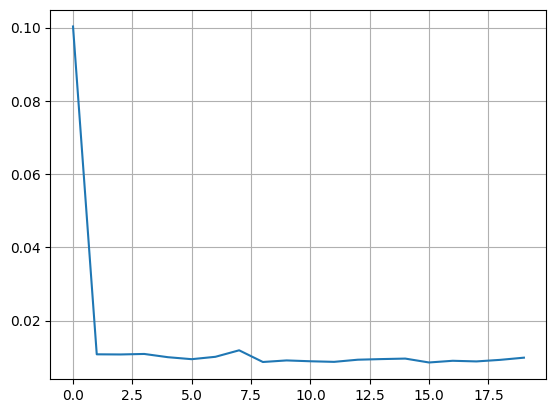

In [128]:
plt.plot(train_loss_list)
plt.grid()
plt.show()

In [129]:
# 예측 데이터
model.eval()
preds = []
trues = []
with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)


In [130]:
preds = torch.cat(preds, 0).squeeze(-1).numpy()
trues = torch.cat(trues, 0).squeeze(-1).numpy()

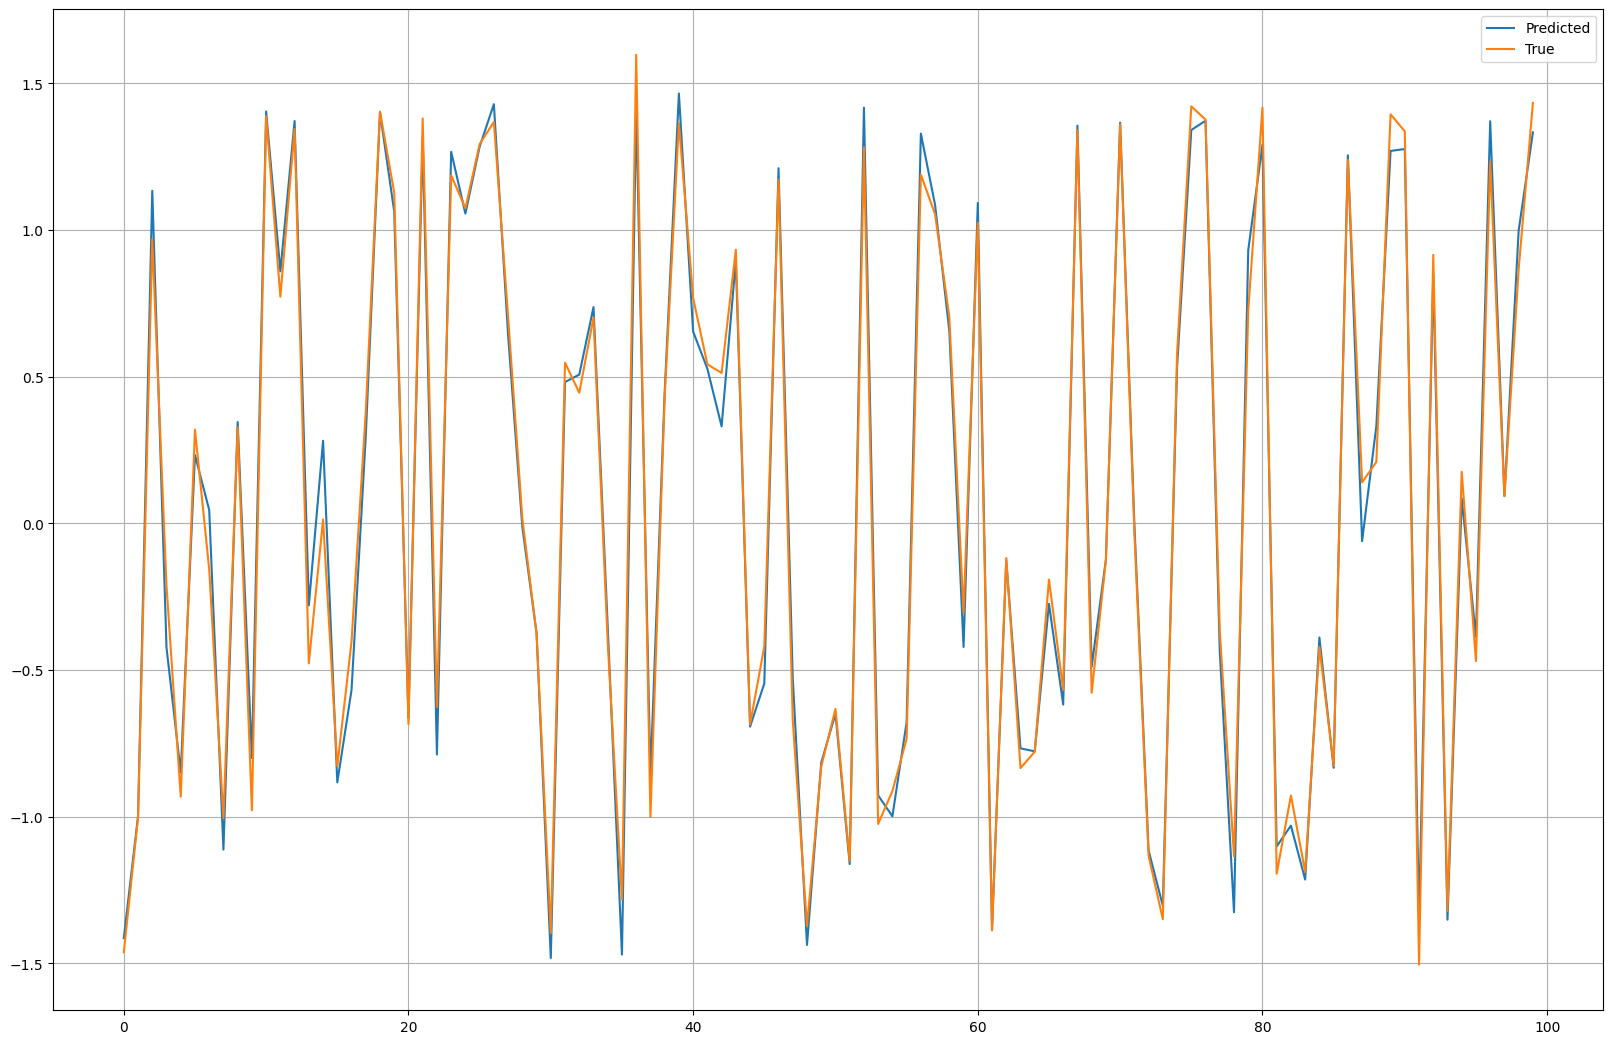

In [131]:
plt.figure(figsize=(20,13))
plt.plot(preds[:100],label = 'Predicted')
plt.plot(trues[:100], label = 'True')
plt.legend()
plt.grid()
plt.show()